# Binomial Distribution

The **Binomial distribution** counts the number of successes in n independent Bernoulli trials, each with probability p. It is the most widely used discrete distribution — modelling coin flips, A/B test conversions, defect counts, and any binary outcome repeated n times.

| Property | Value |
|---|---|
| **Parameters** | n (number of trials), p (success probability, 0 ≤ p ≤ 1) |
| **Support** | {0, 1, 2, …, n} |
| **PMF** | P(X=k) = C(n,k) · p^k · (1−p)^(n−k) |
| **Mean** | np |
| **Variance** | np(1−p) |
| **Std Dev** | √(np(1−p)) |
| **Skewness** | (1−2p)/√(np(1−p)) |
| **Estimation** | p̂ = k/n (MLE = sample proportion) |
| **Normal approx** | Valid when np ≥ 5 and n(1−p) ≥ 5 |
| **Poisson limit** | n→∞, p→0, np→λ: Binomial(n,p) → Poisson(λ) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

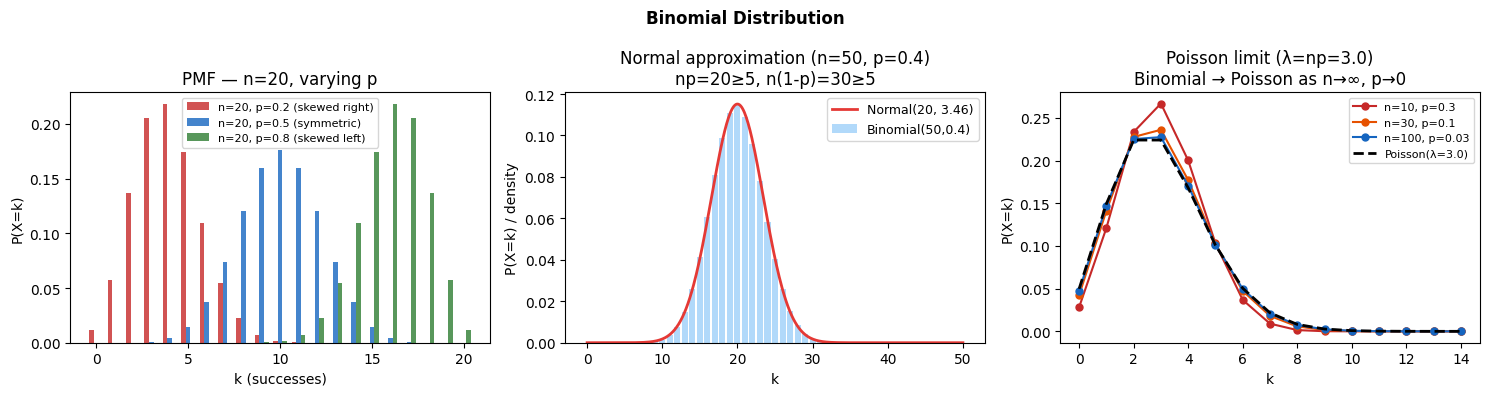

Observed: 37/100 successes, p̂ = 0.370
95% CI (Wald): (0.275, 0.465)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Binomial Distribution', fontsize=12, fontweight='bold')

# PMF — varying p
n = 20
k = np.arange(0, n+1)
for offset, (p, color, label) in zip([-0.25, 0, 0.25],
    [(0.2, '#C62828', 'p=0.2 (skewed right)'),
     (0.5, '#1565C0', 'p=0.5 (symmetric)'),
     (0.8, '#2E7D32', 'p=0.8 (skewed left)')]):
    pmf = stats.binom(n, p).pmf(k)
    axes[0].bar(k + offset, pmf, width=0.25, color=color, alpha=0.8, label=f'n={n}, {label}')
axes[0].set_title('PMF — n=20, varying p')
axes[0].set_xlabel('k (successes)'); axes[0].set_ylabel('P(X=k)')
axes[0].legend(fontsize=8)

# Normal approximation
n, p = 50, 0.4
k_all = np.arange(0, n+1)
pmf_exact = stats.binom(n, p).pmf(k_all)
mu_norm = n*p; sigma_norm = np.sqrt(n*p*(1-p))
x_cont = np.linspace(0, n, 400)
normal_approx = stats.norm(mu_norm, sigma_norm).pdf(x_cont)

axes[1].bar(k_all, pmf_exact, color='#90CAF9', alpha=0.7, label=f'Binomial({n},{p})')
axes[1].plot(x_cont, normal_approx, color='#E53935', linewidth=2,
             label=f'Normal({mu_norm:.0f}, {sigma_norm:.2f})')
axes[1].set_title(f'Normal approximation (n={n}, p={p})\nnp={n*p:.0f}≥5, n(1-p)={n*(1-p):.0f}≥5')
axes[1].set_xlabel('k'); axes[1].set_ylabel('P(X=k) / density')
axes[1].legend(fontsize=9)

# Poisson limit
lam = 3.0
for n_val, color, label in [(10,  '#C62828', 'n=10, p=0.3'),
                              (30,  '#E65100', 'n=30, p=0.1'),
                              (100, '#1565C0', 'n=100, p=0.03')]:
    p_val = lam / n_val
    k_range = np.arange(0, 15)
    pmf = stats.binom(n_val, p_val).pmf(k_range)
    axes[2].plot(k_range, pmf, 'o-', color=color, linewidth=1.5, markersize=5, label=label)
k_range = np.arange(0, 15)
axes[2].plot(k_range, stats.poisson(lam).pmf(k_range), 'k--', linewidth=2,
             label=f'Poisson(λ={lam})')
axes[2].set_title(f'Poisson limit (λ=np={lam})\nBinomial → Poisson as n→∞, p→0')
axes[2].set_xlabel('k'); axes[2].set_ylabel('P(X=k)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Confidence interval for p
k_obs, n_obs = 37, 100
p_hat = k_obs / n_obs
se = np.sqrt(p_hat*(1-p_hat)/n_obs)
ci_lo = p_hat - 1.96*se
ci_hi = p_hat + 1.96*se
print(f"Observed: {k_obs}/{n_obs} successes, p̂ = {p_hat:.3f}")
print(f"95% CI (Wald): ({ci_lo:.3f}, {ci_hi:.3f})")

## Key Takeaways

| | |
|---|---|
| **Independence** | Requires independent trials and constant p — check both |
| **p=0.5** | Symmetric; otherwise skewed toward 0 (p<0.5) or n (p>0.5) |
| **MLE** | p̂ = k/n — the sample proportion |
| **Normal approx** | Use when np ≥ 5 and n(1−p) ≥ 5 (with continuity correction) |
| **Poisson limit** | n→∞, p→0, np=λ fixed: use Poisson when n large and p very small |
| **A/B testing** | Conversion rate difference: compare two Binomials with z-test or exact test |
| **CDF** | Used for hypothesis testing: P(X ≥ k) gives one-tailed p-value |